## 掛載雲端硬碟


In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

## 更改檔案所在路徑

In [2]:
# Change to your own folder !!!
# %cd /content/drive/MyDrive/your own folder/

## Import library

In [3]:
import os
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable

from models.resnet import ResNet50

## FLOPs & Parameters & Architecture
若`resnet.py`有寫對，這部分會能夠正常跑，且 parameters 應為 23513162。

你也可以寫一個剪枝後可能的 cfg 作為模型的輸入參數，看這部分印出來的架構是否正確。

In [4]:
# %pip install thop torchsummary -q

In [5]:
from thop import profile
from torchsummary import summary

model = ResNet50(num_classes=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
model = model.to(device)

dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input, ))

print(f"FLOPs: {flops}")
print(f"Params: {params}")
summary(model, input_size=(3, 32, 32))

Total cfg used: 0
Device: cuda
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 328947712.0
Params: 23513162.0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64,

## 設定超參數(請填空 λ)

In [6]:
SPARSITY_REGULARIZATION = True
#### 設定λ(balance factor) ####
lmbda_list = [0, 1e-5, 1e-4]
LAMBDA = lmbda_list[2]

SEED = 1
TRAIN_BATCH_SIZE = 100
TEST_BATCH_SIZE = 1000

EPOCHS = 40
LEARNING_RATE = 1e-3

LOG_INTERVAL = 100
CUDA = True

RESUME = False
START_EPOCH = 0

WEIGHT_PATH = f"./out/model_best_{LAMBDA}_dummy.pth"  #TODO only for homework submit cause i mess up traing progress

In [7]:
if(torch.cuda.is_available()):
    CUDA = True
    kwargs = {'num_workers': 1, 'pin_memory': True}
    torch.cuda.manual_seed(SEED)
else:
    CUDA = False
    kwargs = {}


## 下載資料集


這裡將訓練集做Augmentation(Pad, RandCrop, Random)，測試集不用做Augmentation

In [8]:
#### 資料集 ####
train_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.Pad(4),
                       transforms.RandomCrop(32),
                       transforms.RandomHorizontalFlip(),
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TRAIN_BATCH_SIZE, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=False, transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
                   ])),
    batch_size=TEST_BATCH_SIZE, shuffle=True, **kwargs)

Files already downloaded and verified


## 定義模型與設定Optimizer & CrossEntropy Loss


In [9]:
model = ResNet50(num_classes=10)
if CUDA:
    model.cuda()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

Total cfg used: 0


## 使用論文中稀疏化的方式更新參數(請填空)

In [10]:
def updateBN():
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            #### 完成Sparsity Regularization ####
            m.weight.grad.data.add_(LAMBDA * torch.sign(m.weight.data))

## 定義訓練跟測試函數
需自行撰寫儲存每個epoch之train acc與test acc的code，以便後續繪製train acc與test acc結果圖!

In [11]:
#### 訓練函數 #####

# 注意: 需自行撰寫儲存每個epoch之train acc與test acc的code，以便後續繪製train acc與test acc結果圖!

def train(epoch):
    model.train()
    correct = 0
    total = 0
    running_loss = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        if CUDA:
            data, target = data.cuda(), target.cuda()

        data, target = Variable(data), Variable(target)

        optimizer.zero_grad()
        output = model(data)

        loss = criterion(output, target)
        loss.backward()

        if SPARSITY_REGULARIZATION:
            updateBN()
        optimizer.step()

        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).cpu().sum()
        total += target.size(0)
        running_loss += loss.item()

        if batch_idx % LOG_INTERVAL == 0:
            print('Train Epoch: {} [{}/{} ({:.1f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.data.item()))

    train_acc = 100. * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Train Accuracy: {train_acc:.2f}% | Avg Loss: {avg_loss:.4f}")
    return train_acc

#### 測試函數 ####
def test():
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
      for data, target in test_loader:
          if CUDA:
              data, target = data.cuda(), target.cuda()
          data, target = Variable(data), Variable(target)

          output = model(data)
          loss = criterion(output, target)
          test_loss += loss.item() * data.size(0)

          pred = output.data.max(1, keepdim=True)[1]
          correct += pred.eq(target.data.view_as(pred)).cpu().sum()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.1f}%)\n'.format(
          test_loss, correct, len(test_loader.dataset),
          100. * correct / len(test_loader.dataset)))
    return correct / float(len(test_loader.dataset))

##########################################################################################

best_prec1 = 0.
train_acc_list = []
test_acc_list = []

for epoch in range(START_EPOCH, EPOCHS):
    # Learning Rate在0.5EPOCHS與0.75EPOCHS調整為原本1/10

    if epoch in [EPOCHS*0.5, EPOCHS*0.75]:
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.1
    train(epoch)
    prec1 = test()
    train_acc = train(epoch)
    test_acc = test()
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    # 儲存模型權重，方便做後續剪枝,後續訓練
    if(prec1 > best_prec1):
        best_prec1 = prec1
        torch.save({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'best_prec1': best_prec1,
            'optimizer': optimizer.state_dict(),
        }, WEIGHT_PATH)

    best_prec1 = max(prec1, best_prec1)

Train Epoch: 0 [0/50000 (0.0%)]	Loss: 2.410621
Train Epoch: 0 [10000/50000 (20.0%)]	Loss: 1.694372
Train Epoch: 0 [20000/50000 (40.0%)]	Loss: 1.867154
Train Epoch: 0 [30000/50000 (60.0%)]	Loss: 1.706999
Train Epoch: 0 [40000/50000 (80.0%)]	Loss: 1.616303
Train Accuracy: 34.03% | Avg Loss: 1.8461

Test set: Average loss: 1.5324, Accuracy: 4428/10000 (44.3%)

Train Epoch: 0 [0/50000 (0.0%)]	Loss: 1.510476
Train Epoch: 0 [10000/50000 (20.0%)]	Loss: 1.654308
Train Epoch: 0 [20000/50000 (40.0%)]	Loss: 1.572751
Train Epoch: 0 [30000/50000 (60.0%)]	Loss: 1.532266
Train Epoch: 0 [40000/50000 (80.0%)]	Loss: 1.282946
Train Accuracy: 47.50% | Avg Loss: 1.4459

Test set: Average loss: 1.2925, Accuracy: 5378/10000 (53.8%)

Train Epoch: 1 [0/50000 (0.0%)]	Loss: 1.332480
Train Epoch: 1 [10000/50000 (20.0%)]	Loss: 1.230143
Train Epoch: 1 [20000/50000 (40.0%)]	Loss: 1.071532
Train Epoch: 1 [30000/50000 (60.0%)]	Loss: 1.302899
Train Epoch: 1 [40000/50000 (80.0%)]	Loss: 1.061109
Train Accuracy: 57.63% | 

## 繪製Sparsity-Training結果圖

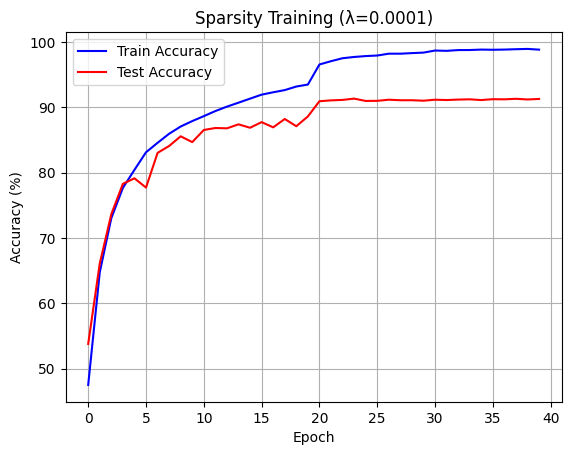

In [12]:
# 繪製 Sparsity-Training 結果圖
import matplotlib.pyplot as plt

test_acc_list = [test*100 for test in test_acc_list]

plt.figure()
plt.plot(train_acc_list, label="Train Accuracy", color="blue")
plt.plot(test_acc_list, label="Test Accuracy", color="red")
plt.title(f"Sparsity Training (λ={LAMBDA})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

## 繪製scaling factor 分布圖

/tmp/ipykernel_17887/273118498.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"out/model_best_{LAMBDA}.pth")["state_dict"])


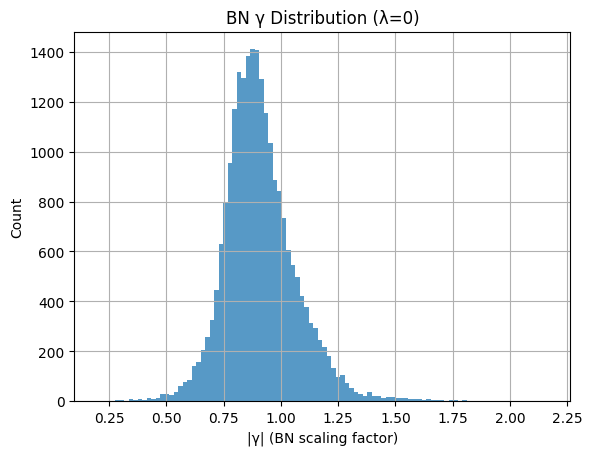

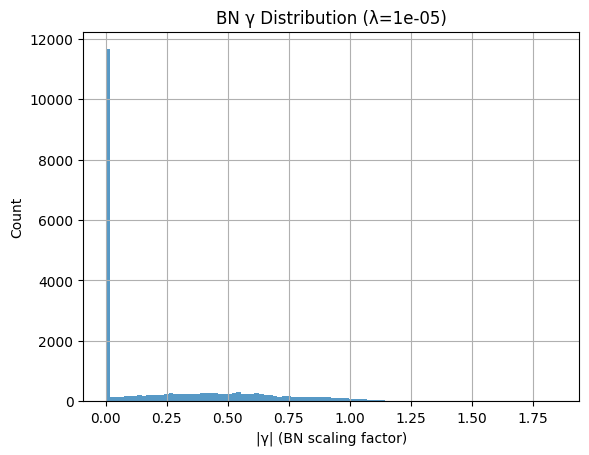

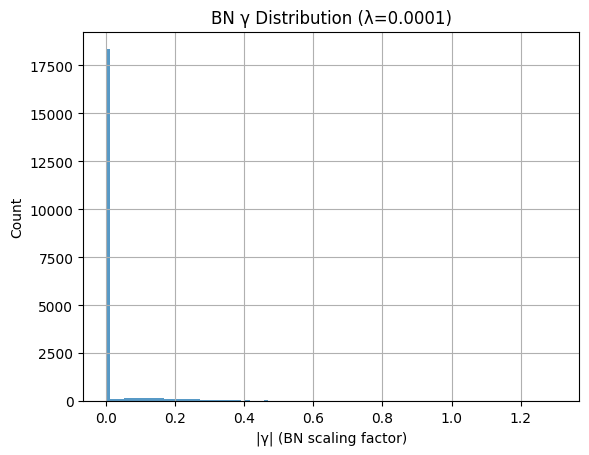

In [13]:
# 繪製 scaling factor 分布圖
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn


def plot_gamma_distribution(model, title):
    gammas = []
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            gammas.append(m.weight.data.abs().cpu().numpy())

    gammas = np.concatenate(gammas)  # 所有層 γ 展平
    plt.hist(gammas, bins=100, alpha=0.75)
    plt.title(title)
    plt.xlabel("|γ| (BN scaling factor)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()
    
# 三個模型
for LAMBDA in [0, 1e-5, 1e-4]:
    model.load_state_dict(torch.load(f"out/model_best_{LAMBDA}.pth")["state_dict"])
    plot_gamma_distribution(model, f"BN γ Distribution (λ={LAMBDA})")

## 3 in 1 plot


/tmp/ipykernel_17887/3813807537.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(f"out/model_best_{LAMBDA}.pth", map_location="cpu")


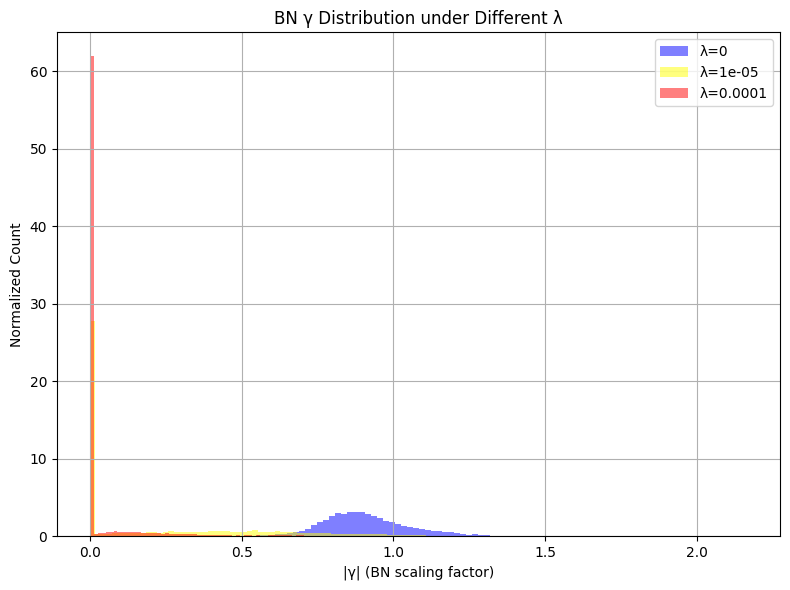

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


def get_all_bn_gammas(model):
    gammas = []
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            gammas.append(m.weight.data.abs().cpu().numpy())
    return np.concatenate(gammas)


# 不同 λ 對應的模型路徑
lambda_list = [0, 1e-5, 1e-4]
colors = ["blue", "yellow", "red"]

plt.figure(figsize=(8, 6))

for LAMBDA, color in zip(lambda_list, colors):
    ckpt = torch.load(f"out/model_best_{LAMBDA}.pth", map_location="cpu")
    model.load_state_dict(ckpt["state_dict"])
    gammas = get_all_bn_gammas(model)
    plt.hist(
        gammas,
        bins=100,
        alpha=0.5,
        label=f"λ={LAMBDA}",
        color=color,
        density=True,  # 正規化 y 軸，方便比較形狀
    )

plt.title("BN γ Distribution under Different λ")
plt.xlabel("|γ| (BN scaling factor)")
plt.ylabel("Normalized Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()